In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

For this notebook, you can reproduce the exact results I have if you run every cell, in order, a single time. The PRNG uses a constant seed.

# Psuedo Random Number Generator

In [2]:
class LinearCongruentialGenerator:
    def __init__(self, x0=69069, a=25214903917, b=11, M=2**48):
        """ initialized using the parameters used by Unix drand48()"""
        self.x_now = x0
        self.a = a
        self.b = b
        self.M = M


    def random(self):
        self.x_now = (self.a * self.x_now + self.b) % self.M
        return self.x_now / self.M


class FibonacciGenerator:
    def __init__(self, x0=69069, lag1=607, lag2=273):
        """
        initalized using the parameters used by Go's (Google's C++ replacement) random number generator.eca
        these parameters yield a period of 2^669.
        """
        self.lag1 = lag1
        self.lag2 = lag2

        initializer = LinearCongruentialGenerator(x0=x0)
        self.state = [initializer.random() for _ in range(lag1)]


    def random(self):
        x_now = (self.state[-self.lag1] + self.state[-self.lag2]) % 1

        self.state.append(x_now)
        self.state.pop(0)

        return x_now


random = FibonacciGenerator()

# Question 2

- assuming inifinite medium
- assuming no scattering

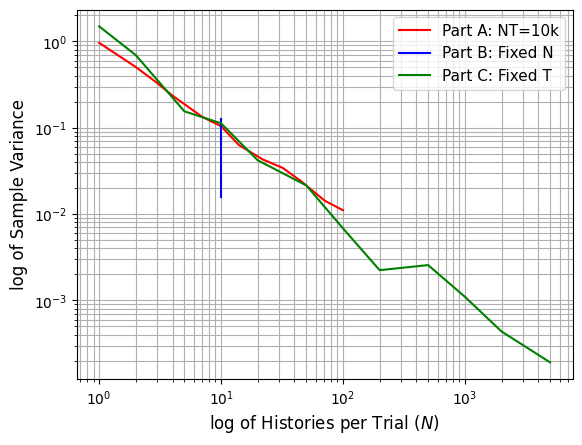

----- Part A -----
N     T     mean     var  
100   100   1.00146  1.10967e-02
71    141   0.99546  1.42815e-02
45    222   1.01477  2.42838e-02
32    312   1.00637  3.43755e-02
22    455   1.00159  4.29568e-02
14    714   0.99411  6.31923e-02
10    1000  1.00270  1.04315e-01
7     1429  1.00950  1.33934e-01
4     2500  0.97346  2.35530e-01
3     3333  0.98708  3.29299e-01
2     5000  1.00644  5.05561e-01
1     10000 1.00039  9.64707e-01

----- Part B -----
N     T     mean     var  
10    10    1.00571  1.56608e-02
10    20    0.89199  7.77478e-02
10    30    1.04562  7.48802e-02
10    40    1.03413  7.70872e-02
10    50    1.02438  1.25086e-01
10    100   1.01608  1.04676e-01
10    200   0.96787  1.03252e-01
10    500   0.99986  1.09756e-01
10    1000  1.02049  1.09611e-01

----- Part C -----
N     T     mean     var  
1     20    1.10834  1.49779e+00
2     20    0.94039  6.93988e-01
5     20    1.00156  1.55274e-01
10    20    0.96930  1.12675e-01
20    20    1.03084  4.20317e-02
50

In [3]:
Sigma = 1
epsilon = 1e-15
sample_r = lambda eta: -np.log(np.maximum(eta, epsilon))


# simulation functions
def run_batch(n_histories):
    trial_sample_mean = 0
    
    for _ in range(n_histories):
        trial_sample_mean += sample_r(random.random())

    return trial_sample_mean / n_histories


def run_simulation(n_trials, n_histories):
    trial_means = [run_batch(n_histories) for _ in range(n_trials)]
    return np.array(trial_means)


def calc_mean_var(n_trials, n_histories):
    trial_means = run_simulation(n_trials, n_histories)

    total_mean = np.mean(trial_means)
    sample_variance = 1 / (n_trials - 1) * np.sum((trial_means - total_mean)**2)

    return total_mean, sample_variance
    

# running simulations ---------------------------------------------------------
# part a: fixed experiments
partA_n_experiments = 10_000
partA_ratios = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000]

partA_results = []

for ratio in partA_ratios:
    n_histories = (partA_n_experiments / ratio)**(1/2)
    n_histories = round(n_histories)

    n_trials = round(partA_n_experiments / n_histories)

    mean, variance = calc_mean_var(n_trials, n_histories)
    partA_results.append((n_histories, n_trials, mean, variance))


# part b: fixed histories per trial/particles
partB_n_histories = 10
partB_n_trials = [10, 20, 30, 40, 50, 100, 200, 500, 1000]

partB_results = []

for n_trials in partB_n_trials:
    mean, variance = calc_mean_var(n_trials, partB_n_histories)
    partB_results.append((partB_n_histories, n_trials, mean, variance))


# part c: fixed trials/batches
partC_n_trials = 20
partC_n_histories = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000]

partC_results = []

for n_histories in partC_n_histories:
    mean, variance = calc_mean_var(partC_n_trials, n_histories)
    partC_results.append((n_histories, partC_n_trials, mean, variance))
# -----------------------------------------------------------------------------

# output ----------------------------------------------------------------------
def plot_variance_wrt_histories(resultsA, resultsB, resultsC):
    nA_histories, _, _, varAs = zip(*resultsA)
    nB_histories, _, _, varBs = zip(*resultsB)
    nC_histories, _, _, varCs = zip(*resultsC)


    plt.plot(nA_histories, varAs, c="r", label="Part A: NT=10k")
    plt.plot(nB_histories, varBs, c="b", label="Part B: Fixed N")
    plt.plot(nC_histories, varCs, c="g", label="Part C: Fixed T")

    plt.xscale("log")
    plt.yscale("log")

    plt.xlabel('log of Histories per Trial ($N$)', fontsize=12)
    plt.ylabel('log of Sample Variance', fontsize=12)
    plt.grid(True, which="both")
    plt.legend(fontsize=11)

    #plt.savefig("hw03q2.png", dpi=600)
    plt.show()


# output
plot_variance_wrt_histories(partA_results, partB_results, partC_results)

print("----- Part A -----")
print(f"{"N":<5} {"T":<5} {"mean":<8} {"var":<5}")
for n, t, mean, var in partA_results:
    str_out = f"{n:<5} {t:<5} {mean:<8.5f} {var:<9.5e}"
    print(str_out)

print("\n----- Part B -----")
print(f"{"N":<5} {"T":<5} {"mean":<8} {"var":<5}")
for n, t, mean, var in partB_results:    
    str_out = f"{n:<5} {t:<5} {mean:<8.5f} {var:<9.5e}"
    print(str_out)

print("\n----- Part C -----")
print(f"{"N":<5} {"T":<5} {"mean":<8} {"var":<5}")
for n, t, mean, var in partC_results:    
    str_out = f"{n:<5} {t:<5} {mean:<8.5f} {var:<9.5e}"
    print(str_out)
# -----------------------------------------------------------------------------

# Question 3

## Obtaining Trial Statistics

In [4]:
# parameters
n_global_samples = 2**20

trial1_parameters = (100, 100)
trial2_parameters = (20, 500)

epsilon = 1e-15


# Using Box-Muller Procedure from "Topic 1: Random Variales and Sampling"
def sample_using_box_muller():
    eta1 = max(random.random(), 1e-15)
    eta2 = random.random()

    sampled_x = (-2 * np.log(eta1))**(1/2) * np.cos(2 * np.pi * eta2)
    return sampled_x


# sampling
def get_trial_means(parameters):
    n_samples, n_trials = parameters
    
    global_samples = np.array([sample_using_box_muller() for _ in range(n_global_samples)])
    global_trial_indices = set()
    trial_means = []
    
    for trial in range(n_trials):
        trial_indices = []
    
        while len(trial_indices) < n_samples:
            sampled_index = int(random.random() * n_global_samples)
            
            if sampled_index not in global_trial_indices:
                trial_indices.append(sampled_index)
                global_trial_indices.add(sampled_index)
    
        trial_samples = global_samples[trial_indices]
        trial_means.append(np.mean(trial_samples))

    return trial_means


# results
t1_means = get_trial_means(trial1_parameters)
t2_means = get_trial_means(trial2_parameters)

t1_total_mean = np.mean(t1_means)
t2_total_mean = np.mean(t2_means)

t1_variance = 1 / (len(t1_means) - 1) * np.sum((t1_means - t1_total_mean)**2)
t2_variance = 1 / (len(t2_means) - 1) * np.sum((t2_means - t2_total_mean)**2)

## Part A: Comparing Histograms

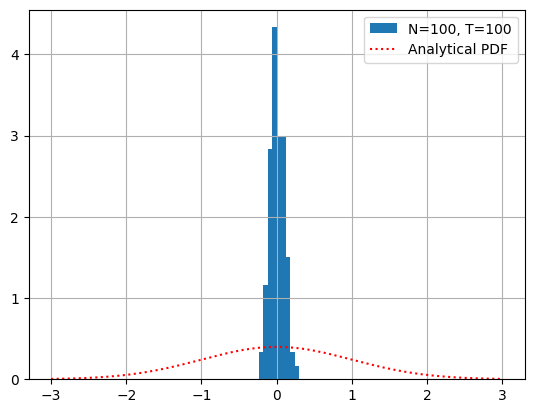

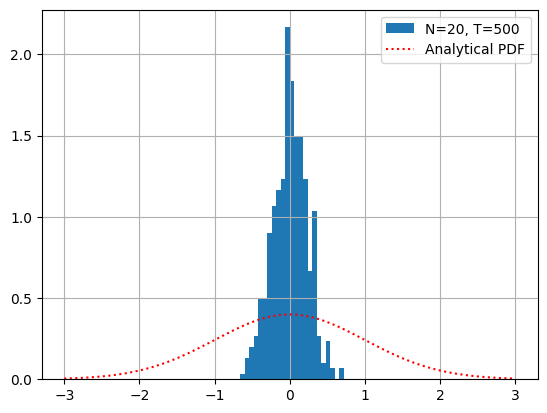

In [5]:
epsilon = 1e-15
x_start, x_end = -3, 3

pdf_gaussian = lambda x: 1 / (2 * np.pi)**(1/2) * np.exp(-x**2 / 2)


def plot_trial_histogram(parameters, n_bins): 
    trial_means = get_trial_means(parameters)
    N, T = parameters
    
    plt.hist(
        trial_means, bins=n_bins, density=True,
        label=f"N={N}, T={T}", range=(x_start, x_end)
    )
    

# plotting
xs = np.linspace(x_start, x_end, 10_000)
ys = pdf_gaussian(xs)

# trial 1
plot_trial_histogram(trial1_parameters, n_bins=100)
plt.plot(xs, ys, color="r", ls=":", label="Analytical PDF")

plt.grid(which="both")
plt.legend()

#plt.savefig("hw03q3_trial1.png", dpi=600)
plt.show()


# trial 2
plot_trial_histogram(trial2_parameters, n_bins=100)
plt.plot(xs, ys, color="r", ls=":", label="Analytical PDF")

plt.grid(which="both")
plt.legend()

#plt.savefig("hw03q3_trial2.png", dpi=600)
plt.show()

## Part B: Normality Test with Skewnewss Coefficient

In [6]:
# scipy skewness
t1_C_biased = stats.skew(t1_means, bias=True)
t2_C_biased = stats.skew(t2_means, bias=True)

t1_C_unbiased = stats.skew(t1_means, bias=False)
t2_C_unbiased = stats.skew(t2_means, bias=False)

# calculating skewness coefficient by ourselves
t1_C = 1 / len(t1_means) * np.sum((t1_means - t1_total_mean)**3) / t1_variance**(3/2)
t2_C = 1 / len(t2_means) * np.sum((t2_means - t2_total_mean)**3) / t2_variance**(3/2)


# thresholds
def get_thresholds(T):
    multiplier = 6 * (T - 1) * (T - 2) / T / (T + 1) / (T + 3)

    doubtful_c2 = 1.96**2 * multiplier
    meaningless_c2 = 2.81**2 * multiplier

    doubtful_c = doubtful_c2**(1/2)
    meaningless_c = meaningless_c2**(1/2)

    return doubtful_c2, doubtful_c, meaningless_c2, meaningless_c


t1_dc2, t1_dc, t1_mc2, t1_mc = get_thresholds(len(t1_means))
t2_dc2, t2_dc, t2_mc2, t2_mc = get_thresholds(len(t2_means))



print("----- Trial 1 -----")
print(f"From Lecture Slides:     {t1_C}")
print(f"Scipy Biased (default):  {t1_C_biased}")
print(f"Scipy Unbiased:          {t1_C_unbiased}")

print(f"\nT={len(t1_means)} thresholds")
print(f"    Doubtful:     C^2 >= {t1_dc2:.6f}, |C| >= {t1_dc:.6f}")
print(f"    Meaningless:  C^2 >= {t1_mc2:.6f}, |C| >= {t1_mc:.6f}")


print("\n\n----- Trial 2 -----")
print(f"From Lecture Slides:     {t2_C}")
print(f"Scipy Biased (default):  {t2_C_biased}")
print(f"Scipy Unbiased:          {t2_C_unbiased}")

print(f"\nT={len(t2_means)} thresholds")
print(f"    Doubtful:     C^2 >= {t2_dc2:.6f}, |C| >= {t2_dc:.6f}")
print(f"    Meaningless:  C^2 >= {t2_mc2:.6f}, |C| >= {t2_mc:.6f}")

----- Trial 1 -----
From Lecture Slides:     0.016970816924179045
Scipy Biased (default):  0.017228598752162642
Scipy Unbiased:          0.0174920809360741

T=100 thresholds
    Doubtful:     C^2 >= 0.214964, |C| >= 0.463642
    Meaningless:  C^2 >= 0.441842, |C| >= 0.664712


----- Trial 2 -----
From Lecture Slides:     -0.024156488595341218
Scipy Biased (default):  -0.024229139658483473
Scipy Unbiased:          -0.02430210681940304

T=500 thresholds
    Doubtful:     C^2 >= 0.045459, |C| >= 0.213211
    Meaningless:  C^2 >= 0.093437, |C| >= 0.305674


## Part C: Normality Test with Shapiro-Wilk test

In [7]:
t1_w, t1_p = stats.shapiro(t1_means)
t2_w, t2_p = stats.shapiro(t2_means)

print("----- Trial 1 -----")
print(f"W = {t1_w}, p = {t1_p}")

print("\n----- Trial 2 -----")
print(f"W = {t2_w}, p = {t2_p}")

----- Trial 1 -----
W = 0.9943210797460217, p = 0.9535446042794788

----- Trial 2 -----
W = 0.9981458023450841, p = 0.8717446038506165


# Question 4

In [8]:
mean = 5

# part 1
p1_n_samples = 30
p1_sample_mean = 4.8
p1_std_dev = 0.4

p1_T = abs((p1_sample_mean - mean) / (p1_std_dev / (p1_n_samples)**(1/2)))

p1_T_90 = 1.699
p1_T_95 = 2.045

p1_ci_90 = p1_T_90 * p1_std_dev / (p1_n_samples)**(1/2)
p1_ci_95 = p1_T_95 * p1_std_dev / (p1_n_samples)**(1/2)

print("----- Part 1 -----")
print(f"Calculated t-value:      {p1_T:.4f}")
print(f"Critical t-value (90%):  {p1_T_90:.3f}")
print(f"Critical t-value (95%):  {p1_T_95:.3f}")
print(f"90% Confidence interval: {p1_ci_90:.5f}")
print(f"    {p1_sample_mean - p1_ci_90:.5f}, {p1_sample_mean + p1_ci_90:.5f}")
print(f"95% Confidence interval: {p1_ci_95:.5f}")
print(f"    {p1_sample_mean - p1_ci_95:.5f}, {p1_sample_mean + p1_ci_95:.5f}")


# part 2
p2_n_samples = 50
p2_sample_mean = 4.8
p2_true_std_dev = 0.5

p2_Z = abs((p2_sample_mean - mean) / (p2_true_std_dev / (p2_n_samples)**(1/2)))

p2_Z_90 = 1.645
p2_Z_95 = 1.960

p2_ci_90 = p2_Z_90 * p2_true_std_dev / (p2_n_samples)**(1/2)
p2_ci_95 = p2_Z_95 * p2_true_std_dev / (p2_n_samples)**(1/2)

print("\n----- Part 2 -----")
print(f"Calculated z-value:     {p2_Z:.4f}")
print(f"Critical z-value (90%): {p2_Z_90:.3f}")
print(f"Critical z-value (95%): {p2_Z_95:.3f}")
print(f"90% Confidence interval: {p2_ci_90:.5f}")
print(f"    {p2_sample_mean - p2_ci_90:.5f}, {p2_sample_mean + p2_ci_90:.5f}")
print(f"95% Confidence interval: {p2_ci_95:.5f}")
print(f"    {p2_sample_mean - p2_ci_95:.5f}, {p2_sample_mean + p2_ci_95:.5f}")

----- Part 1 -----
Calculated t-value:      2.7386
Critical t-value (90%):  1.699
Critical t-value (95%):  2.045
90% Confidence interval: 0.12408
    4.67592, 4.92408
95% Confidence interval: 0.14935
    4.65065, 4.94935

----- Part 2 -----
Calculated z-value:     2.8284
Critical z-value (90%): 1.645
Critical z-value (95%): 1.960
90% Confidence interval: 0.11632
    4.68368, 4.91632
95% Confidence interval: 0.13859
    4.66141, 4.93859
